In [2]:
import matplotlib.gridspec as gridspec
import scqubits
import numpy as np
from CoupledQuantumSystems.visualization import *
from CoupledQuantumSystems.systems import *
from tqdm import tqdm
from CoupledQuantumSystems.qobj_manip import *
# linestyles = ['-',(0,(3,1,1,1)),(0,(5,2,5,2))]
# linestyles = ['-','--',':']

linestyles = ['-',(3,(2,4,5,1)),(0,(3,3,3,3))]
linewidth_list = [1,1.75,2.5]

colors = ['black','#d5373d','#4999c3']

In [4]:
def plot_sweep_Er(ax,matrix, evals,Er_list,qls = [0,1,2],ylim=(-1,1),participating_transitions = None):
    num_evals =len(evals)

    if participating_transitions != None:
        for i in range(num_evals):
                for j in range(num_evals): 
                    if (i, j) not in participating_transitions and (j, i) not in participating_transitions:
                        matrix[i, j] = 0 

    for ql  in qls:
        color  = colors[ql]
        linestyle = linestyles[ql]
        shift_from_qubit_transition = []
        for Er in tqdm(Er_list, desc = "Er loop"):
            shifts = [get_shift_accurate(matrix[ql,ql2], evals[ql2], evals[ql], Er) for ql2 in range(num_evals)] 
            shift_from_qubit_transition.append(sum(shifts))
        ax.plot(Er_list, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = color, linestyle = linestyle)

    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.minorticks_on()
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    ax.set_xlim(Er_list[0],Er_list[-1])
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xlabel(rf'$\omega_r$')
    ax.legend()

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 86127.46it/s]
 /var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_3758/2372158479.py: 77

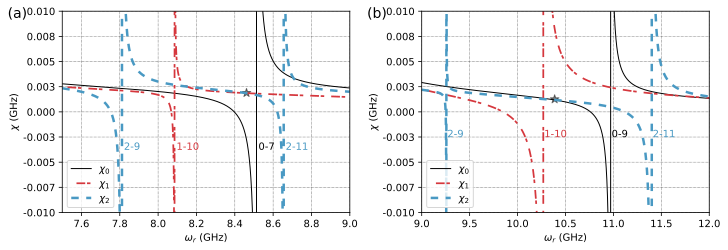

In [14]:
n_evals = 20
qls = [0,1,2]
max_ol = 50
max_ql = 20

fig = plt.figure(figsize=(10, 3.5)) 
gs0 = fig.add_gridspec(nrows=1, ncols=1,left=0.09, right=0.49,bottom=0.15,top = 0.95)
gs1 = fig.add_gridspec(nrows=1, ncols=1,left=0.59, right=0.99,bottom=0.15,top = 0.95)
ax0 = fig.add_subplot(gs0[0])
ax1 = fig.add_subplot(gs1[0])


plt.text(-0.19, 1.02, '(a)', transform=plt.subplot(gs0[0]).transAxes, fontsize=14, va='top', color='black')
plt.text(-0.19, 1.02, '(b)', transform=plt.subplot(gs1[0]).transAxes, fontsize=14, va='top', color='black')


####################################################
# a
#
####################################################

qbt0 = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/20.5, cutoff = 110,flux = 0,truncated_dim=n_evals)
matrix0 =  qbt0.matrixelement_table(operator = "n_operator",evals_count=n_evals)
evals0 = qbt0.eigenvals(n_evals)
Er_list0 = np.linspace(7.5,9,int(1e4))
ylim  = (-0.01,0.01) # in GHz
for ql  in qls:
    shift_from_qubit_transition = []
    for Er in tqdm(Er_list0, desc = "Er loop"):
        shifts = [get_shift_accurate(matrix0[ql,ql2], evals0[ql2], evals0[ql], Er) for ql2 in range(n_evals)] 
        shift_from_qubit_transition.append(sum(shifts)/100)
    ax0.plot(Er_list0, 2*np.pi* np.array(shift_from_qubit_transition), label=rf'$\chi_{ql}$',color = colors[ql], linestyle = linestyles[ql],linewidth = linewidth_list[ql])

ax0.grid(which='major', linestyle=':', linewidth='0.5', color='black')
ax0.set_xlim(Er_list0[0],Er_list0[-1])
ax0.set_ylim(ylim[0],ylim[1])
ax0.set_xlabel(rf'$\omega_r$')
ax0.legend(loc= 'lower left')
ax0.set_xlabel(rf'$\omega_r$ (GHz)')
ax0.set_yticklabels([f'{val:.3f}' for val in ax0.get_yticks()])
ax0.set_ylabel(r'$\chi$ (GHz)')
ax0.scatter(8.46111172,0.0003*2*np.pi, marker='*', color='black', s=80,alpha=0.5)

y_offset = -0.0006
x_offset = 0.01
ax0.text(evals0[9]-evals0[2]+x_offset, 2*np.pi* (y_offset),'2-9',color = colors[2])
ax0.text(evals0[10]-evals0[1]+x_offset, 2*np.pi* (y_offset),'1-10',color = colors[1])
ax0.text(evals0[7]-evals0[0]+x_offset, 2*np.pi* (y_offset),'0-7',color = colors[0])
ax0.text(evals0[11]-evals0[2]+x_offset, 2*np.pi* (y_offset),'2-11',color = colors[2])



####################################################
# b 
#
####################################################
EJ_over_EC = 2.7
EJ_over_EL = 45
qbt1 = scqubits.Fluxonium(EJ = 4,EC = 4/EJ_over_EC,EL = 4/EJ_over_EL, cutoff = 110,flux = 0,truncated_dim=n_evals)
evals1 = qbt1.eigenvals(n_evals)
matrix1 =  qbt1.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list1 = np.linspace(9,12,int(1e4))
ylim  = (-0.01,0.01)
for ql  in qls:
    shift_from_qubit_transition = []
    for Er in tqdm(Er_list1, desc = "Er loop"):
        shifts = [get_shift_accurate(matrix1[ql,ql2], evals1[ql2], evals1[ql], Er) for ql2 in range(n_evals)] 
        shift_from_qubit_transition.append(sum(shifts)/100)
    ax1.plot(Er_list1,2*np.pi* np.array(shift_from_qubit_transition), label=rf'$\chi_{ql}$',color = colors[ql], linestyle = linestyles[ql],linewidth = linewidth_list[ql])

ax1.grid(which='major', linestyle=':', linewidth='0.5', color='black')
ax1.set_xlim(Er_list1[0],Er_list1[-1])
ax1.set_ylim(ylim[0],ylim[1])
ax1.set_xlabel(rf'$\omega_r$')
ax1.legend(loc= 'lower left')
ax1.set_xlabel(rf'$\omega_r$ (GHz)')
ax1.set_yticklabels([f'{val:.3f}' for val in ax0.get_yticks() ])
ax1.set_ylabel(r'$\chi$ (GHz)')
ax1.scatter(10.38695526,0.0002*2*np.pi, marker='*', color='black', s=80,alpha=0.5)

y_offset = -0.0004
x_offset = 0.01
ax1.text(evals1[9]-evals1[2]+x_offset, 2*np.pi* (y_offset),'2-9',color = colors[2])
ax1.text(evals1[10]-evals1[1]+x_offset, 2*np.pi* (y_offset),'1-10',color = colors[1])
ax1.text(evals1[9]-evals1[0]+x_offset, 2*np.pi* (y_offset),'0-9',color = colors[0])
ax1.text(evals1[11]-evals1[2]+x_offset, 2*np.pi* (y_offset),'2-11',color = colors[2])


fig.savefig('dispersive_shift_sweep.pdf')

In [15]:
2*np.pi*(10.389507326769074 - 10.387331537959028)

0.013670884282806698

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 86643.24it/s]
 /var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_3758/3286043483.py: 108

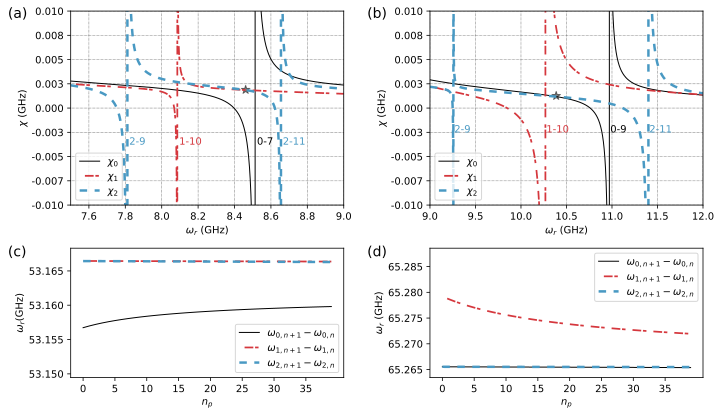

In [17]:
n_evals = 20
qls = [0,1,2]
max_ol = 50
max_ql = 20

fig = plt.figure(figsize=(10, 6)) 
gs0 = fig.add_gridspec(nrows=1, ncols=1,left=0.1, right=0.48,bottom=0.5,top = 0.95)
gs1 = fig.add_gridspec(nrows=1, ncols=1,left=0.6, right=0.98,bottom=0.5,top = 0.95)
ax0 = fig.add_subplot(gs0[0])
ax1 = fig.add_subplot(gs1[0])
gs2 = fig.add_gridspec(nrows=1, ncols=1,left=0.1, right=0.48,bottom=0.1,top = 0.4)
gs3 = fig.add_gridspec(nrows=1, ncols=1,left=0.6, right=0.98,bottom=0.1,top = 0.4)
ax2 = fig.add_subplot(gs2[0])
ax3 = fig.add_subplot(gs3[0])

plt.text(-0.23, 1.02, '(a)', transform=plt.subplot(gs0[0]).transAxes, fontsize=14, va='top', color='black')
plt.text(-0.23, 1.02, '(b)', transform=plt.subplot(gs1[0]).transAxes, fontsize=14, va='top', color='black')
plt.text(-0.23, 1.02, '(c)', transform=plt.subplot(gs2[0]).transAxes, fontsize=14, va='top', color='black')
plt.text(-0.23, 1.02, '(d)', transform=plt.subplot(gs3[0]).transAxes, fontsize=14, va='top', color='black')

####################################################
# a
#
####################################################

qbt0 = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/20.5, cutoff = 110,flux = 0,truncated_dim=n_evals)
matrix0 =  qbt0.matrixelement_table(operator = "n_operator",evals_count=n_evals)
evals0 = qbt0.eigenvals(n_evals)
Er_list0 = np.linspace(7.5,9,int(1e4))
ylim  = (-0.01,0.01) # in GHz
for ql  in qls:
    shift_from_qubit_transition = []
    for Er in tqdm(Er_list0, desc = "Er loop"):
        shifts = [get_shift_accurate(matrix0[ql,ql2], evals0[ql2], evals0[ql], Er) for ql2 in range(n_evals)] 
        shift_from_qubit_transition.append(sum(shifts)/100)
    ax0.plot(Er_list0, 2*np.pi* np.array(shift_from_qubit_transition), label=rf'$\chi_{ql}$',color = colors[ql], linestyle = linestyles[ql],linewidth = linewidth_list[ql])

ax0.grid(which='major', linestyle=':', linewidth='0.5', color='black')
ax0.set_xlim(Er_list0[0],Er_list0[-1])
ax0.set_ylim(ylim[0],ylim[1])
ax0.set_xlabel(rf'$\omega_r$')
ax0.legend(loc= 'lower left')
ax0.set_xlabel(rf'$\omega_r$ (GHz)')
ax0.set_yticklabels([f'{val:.3f}' for val in ax0.get_yticks()])
ax0.set_ylabel(r'$\chi$ (GHz)')
ax0.scatter(8.46111172,0.0003*2*np.pi, marker='*', color='black', s=80,alpha=0.5)

y_offset = -0.0006
x_offset = 0.01
ax0.text(evals0[9]-evals0[2]+x_offset, 2*np.pi* (y_offset),'2-9',color = colors[2])
ax0.text(evals0[10]-evals0[1]+x_offset, 2*np.pi* (y_offset),'1-10',color = colors[1])
ax0.text(evals0[7]-evals0[0]+x_offset, 2*np.pi* (y_offset),'0-7',color = colors[0])
ax0.text(evals0[11]-evals0[2]+x_offset, 2*np.pi* (y_offset),'2-11',color = colors[2])


####################################################
# c 
#
####################################################
system = FluxoniumOscillatorSystem(
    EJ = 3,EC = 3/4,EL = 3/20.5,
    Er = 8.46111172,
    g_strength = 0.2,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '0,2'
    )
energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
n_osc_lvls =40
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))   
for j in [0,1,2]:
    ax2.plot(list(range(max_ol-1))[:n_osc_lvls], 2*np.pi* np.array(dressed_osc_frequencies[j][:n_osc_lvls]),label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$',color = colors[j], linestyle = linestyles[j],linewidth = linewidth_list[j])
ax2.set_xticks(list(range(n_osc_lvls))[::5])
ax2.set_ylim(2*np.pi*8.459, 2*np.pi*8.462)
ax2.legend(loc = 'lower right')
ax2.set_ylabel(rf'$\omega_r$(GHz)')
ax2.set_xlabel(r'$n_p$')
####################################################
# b 
#
####################################################
EJ_over_EC = 2.7
EJ_over_EL = 45
qbt1 = scqubits.Fluxonium(EJ = 4,EC = 4/EJ_over_EC,EL = 4/EJ_over_EL, cutoff = 110,flux = 0,truncated_dim=n_evals)
evals1 = qbt1.eigenvals(n_evals)
matrix1 =  qbt1.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list1 = np.linspace(9,12,int(1e4))
ylim  = (-0.01,0.01)
for ql  in qls:
    shift_from_qubit_transition = []
    for Er in tqdm(Er_list1, desc = "Er loop"):
        shifts = [get_shift_accurate(matrix1[ql,ql2], evals1[ql2], evals1[ql], Er) for ql2 in range(n_evals)] 
        shift_from_qubit_transition.append(sum(shifts)/100)
    ax1.plot(Er_list1,2*np.pi* np.array(shift_from_qubit_transition), label=rf'$\chi_{ql}$',color = colors[ql], linestyle = linestyles[ql],linewidth = linewidth_list[ql])

ax1.grid(which='major', linestyle=':', linewidth='0.5', color='black')
ax1.set_xlim(Er_list1[0],Er_list1[-1])
ax1.set_ylim(ylim[0],ylim[1])
ax1.set_xlabel(rf'$\omega_r$')
ax1.legend(loc= 'lower left')
ax1.set_xlabel(rf'$\omega_r$ (GHz)')
ax1.set_yticklabels([f'{val:.3f}' for val in ax0.get_yticks() ])
ax1.set_ylabel(r'$\chi$ (GHz)')
ax1.scatter(10.38695526,0.0002*2*np.pi, marker='*', color='black', s=80,alpha=0.5)

y_offset = -0.0004
x_offset = 0.01
ax1.text(evals1[9]-evals1[2]+x_offset, 2*np.pi* (y_offset),'2-9',color = colors[2])
ax1.text(evals1[10]-evals1[1]+x_offset, 2*np.pi* (y_offset),'1-10',color = colors[1])
ax1.text(evals1[9]-evals1[0]+x_offset, 2*np.pi* (y_offset),'0-9',color = colors[0])
ax1.text(evals1[11]-evals1[2]+x_offset, 2*np.pi* (y_offset),'2-11',color = colors[2])

####################################################
# d
#
####################################################

system = FluxoniumOscillatorSystem(
   EJ = 4,EC = 4/EJ_over_EC,EL = 4/EJ_over_EL,
    Er = 10.38695526,
    g_strength = 0.2,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '0,2'
    )
energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
n_osc_lvls =40
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))   
for j in [0,1,2]:
    ax3.plot(list(range(max_ol-1))[:n_osc_lvls], 2*np.pi* np.array(dressed_osc_frequencies[j][:n_osc_lvls]),label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$',color = colors[j], linestyle = linestyles[j],linewidth = linewidth_list[j])
ax3.set_xticks(list(range(n_osc_lvls))[::5])
ax3.set_ylim(2*np.pi*10.387, 2*np.pi*10.391)
ax3.legend(loc = 'upper right')
ax3.set_ylabel(rf'$\omega_r$ (GHz)')
ax3.set_xlabel(r'$n_p$')

fig.savefig('dispersive_shift_sweep.pdf')

In [7]:
chi0_list = []
chi1_list = []
chi2_list = []

max_ql = 15
max_ol = 4
flux_list = np.linspace(0,0.5,100)
for flux in tqdm(flux_list,desc='looping: '):
    system = FluxoniumOscillatorSystem(
        EJ = 3,EC = 3/4,EL = 3/20.5,
        Er = 8.46111172,
        g_strength = 0.2,
        fluxonium_flux = flux,
        qubit_level = max_ql,
        osc_level = max_ol,
        computaional_states = '1,2'
        )
    energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
    def dressed_ener(ql,ol):
        return energies[system.product_to_dressed[(ql,ol)]]
    chi0_list.append(dressed_ener(0,1)-dressed_ener(0,0))   
    chi1_list.append(dressed_ener(1,1)-dressed_ener(1,0))   
    chi2_list.append(dressed_ener(2,1)-dressed_ener(2,0))   


looping: 100%|██████████| 100/100 [01:18<00:00,  1.28it/s]


In [9]:
chi0_list_gf = []
chi1_list_gf = []
chi2_list_gf = []

max_ql = 15
max_ol = 4
flux_list = np.linspace(0,0.5,100)
for flux in tqdm(flux_list,desc='looping: '):
    system = FluxoniumOscillatorSystem(
        EJ = 4,EC = 4/2.7,EL = 4/45,
        Er = 10.38695526,
        g_strength = 0.2,
        fluxonium_flux = flux,
        qubit_level = max_ql,
        osc_level = max_ol,
        computaional_states = '0,2'
        )
    energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
    def dressed_ener(ql,ol):
        return energies[system.product_to_dressed[(ql,ol)]]
    chi0_list_gf.append(dressed_ener(0,1)-dressed_ener(0,0))   
    chi1_list_gf.append(dressed_ener(1,1)-dressed_ener(1,0))   
    chi2_list_gf.append(dressed_ener(2,1)-dressed_ener(2,0))   


looping: 100%|██████████| 100/100 [00:33<00:00,  3.02it/s]


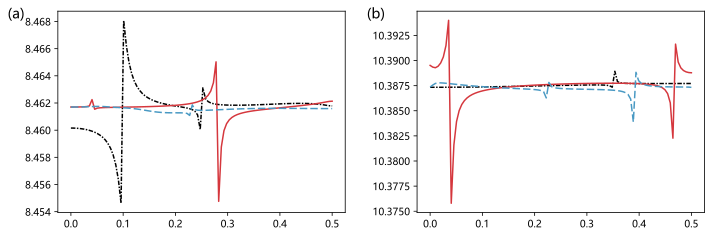

In [10]:
fig = plt.figure(figsize=(10, 3.5)) 
gs0 = fig.add_gridspec(nrows=1, ncols=1,left=0.075, right=0.475,bottom=0.15,top = 0.95)
gs1 = fig.add_gridspec(nrows=1, ncols=1,left=0.575, right=0.975,bottom=0.15,top = 0.95)
ax0 = fig.add_subplot(gs0[0])
ax1 = fig.add_subplot(gs1[0])


plt.text(-0.175, 1.02, '(a)', transform=plt.subplot(gs0[0]).transAxes, fontsize=14, va='top', color='black')
plt.text(-0.175, 1.02, '(b)', transform=plt.subplot(gs1[0]).transAxes, fontsize=14, va='top', color='black')

for i, chi in enumerate([chi0_list,chi1_list,chi2_list]):
    ax0.plot(flux_list,chi,label=rf'$\chi_{{j}}$',color = colors[i], linestyle = linestyles[i])

for i, chi in enumerate([chi0_list_gf,chi1_list_gf,chi2_list_gf]):
    ax1.plot(flux_list,chi,label=rf'$\chi_{{j}}$',color = colors[i], linestyle = linestyles[i])
    

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 106855.53it/s]
 /tmp/ipykernel_4166/3608164479.py: 37

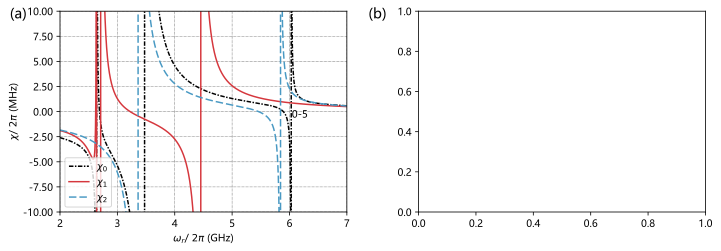

In [85]:
n_evals = 20
qls = [0,1,2]
max_ol = 50
max_ql = 20

fig = plt.figure(figsize=(10, 3.5)) 
gs0 = fig.add_gridspec(nrows=1, ncols=1,left=0.075, right=0.475,bottom=0.15,top = 0.95)
gs1 = fig.add_gridspec(nrows=1, ncols=1,left=0.575, right=0.975,bottom=0.15,top = 0.95)
ax0 = fig.add_subplot(gs0[0])
ax1 = fig.add_subplot(gs1[0])


plt.text(-0.175, 1.02, '(a)', transform=plt.subplot(gs0[0]).transAxes, fontsize=14, va='top', color='black')
plt.text(-0.175, 1.02, '(b)', transform=plt.subplot(gs1[0]).transAxes, fontsize=14, va='top', color='black')


def do_plot_a(qbt0):
    matrix0 =  qbt0.matrixelement_table(operator = "n_operator",evals_count=n_evals)
    evals0 = qbt0.eigenvals(n_evals)
    Er_list0 = np.linspace(2,7,int(1e4))
    ylim  = (-0.01,0.01) # in GHz
    for ql  in qls:
        color  = colors[ql]
        linestyle = linestyles[ql]
        shift_from_qubit_transition = []
        for Er in tqdm(Er_list0, desc = "Er loop"):
            shifts = [get_shift_accurate(matrix0[ql,ql2], evals0[ql2], evals0[ql], Er) for ql2 in range(n_evals)] 
            shift_from_qubit_transition.append(sum(shifts)/100)
        ax0.plot(Er_list0, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = color, linestyle = linestyle)

    ax0.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax0.set_xlim(Er_list0[0],Er_list0[-1])
    ax0.set_ylim(ylim[0],ylim[1])
    ax0.set_xlabel(rf'$\omega_r$')
    ax0.legend(loc= 'lower left')
    ax0.set_xlabel(rf'$\omega_r$/ $2\pi$ (GHz)')
    ax0.set_yticklabels([f'{val:.2f}' for val in ax0.get_yticks() *1000])
    ax0.set_ylabel(r'$\chi$/ $2\pi$ (MHz)')
    ax0.scatter(8.46111172,0.0003, marker='*', color='black', s=80,alpha=0.5)
    y_offset = -0.0006
    x_offset = 0.01
    # ax0.text(evals0[3]-evals0[2]+x_offset, y_offset,'2-3',color = colors[2])
    # ax0.text(evals0[4]-evals0[1]+x_offset, y_offset,'1-4',color = colors[1])
    ax0.text(evals0[5]-evals0[0]+x_offset, y_offset,'0-5',color = colors[0])
    # ax0.text(evals0[5]-evals0[2]+x_offset, y_offset,'2-5',color = colors[2])
qbt0 = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/20.5, cutoff = 110,flux = 0.0,truncated_dim=n_evals)
do_plot_a(qbt0)


def do_plot_b(qbt1):
    evals1 = qbt1.eigenvals(n_evals)
    matrix1 =  qbt1.matrixelement_table(operator = "n_operator",evals_count=n_evals)
    Er_list1 = np.linspace(9,12,int(1e4))
    ylim  = (-0.001,0.001)
    for ql  in qls:
        color  = colors[ql]
        linestyle = linestyles[ql]
        shift_from_qubit_transition = []
        for Er in tqdm(Er_list1, desc = "Er loop"):
            shifts = [get_shift_accurate(matrix1[ql,ql2], evals1[ql2], evals1[ql], Er) for ql2 in range(n_evals)] 
            shift_from_qubit_transition.append(sum(shifts)/100)
        ax1.plot(Er_list1, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = color, linestyle = linestyle)

    ax1.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax1.set_xlim(Er_list1[0],Er_list1[-1])
    ax1.set_ylim(ylim[0],ylim[1])
    ax1.set_xlabel(rf'$\omega_r$')
    ax1.legend(loc= 'lower left')
    ax1.set_xlabel(rf'$\omega_r$/ $2\pi$ (GHz)')
    ax1.set_yticklabels([f'{val:.2f}' for val in ax0.get_yticks() *1000])
    ax1.set_ylabel(r'$\chi$/ $2\pi$ (MHz)')
    ax1.scatter(10.38695526,0.0002, marker='*', color='black', s=80,alpha=0.5)

    y_offset = -0.0004
    x_offset = 0.01
    ax1.text(evals1[9]-evals1[2]+x_offset, y_offset,'2-9',color = colors[2])
    ax1.text(evals1[10]-evals1[1]+x_offset, y_offset,'1-10',color = colors[1])
    ax1.text(evals1[9]-evals1[0]+x_offset, y_offset,'0-9',color = colors[0])
    ax1.text(evals1[11]-evals1[2]+x_offset, y_offset,'2-11',color = colors[2])
# EJ_over_EC = 2.7
# EJ_over_EL = 45
# qbt1 = scqubits.Fluxonium(EJ = 4,EC = 4/EJ_over_EC,EL = 4/EJ_over_EL, cutoff = 110,flux = 0,truncated_dim=n_evals)
# do_plot_b(qbt1)

fig.savefig('dispersive_shift_three_outcome.pdf')

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 108682.69it/s]
 /tmp/ipykernel_4166/4171553109.py: 38

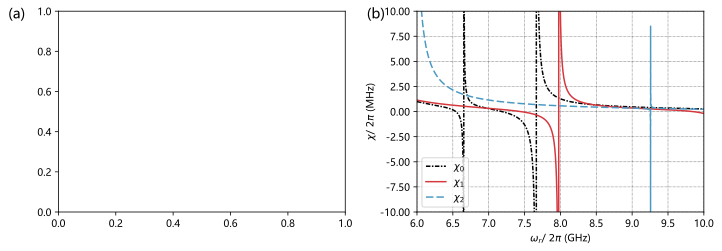

In [107]:
n_evals = 20
qls = [0,1,2]
max_ol = 50
max_ql = 20

fig = plt.figure(figsize=(10, 3.5)) 
gs0 = fig.add_gridspec(nrows=1, ncols=1,left=0.075, right=0.475,bottom=0.15,top = 0.95)
gs1 = fig.add_gridspec(nrows=1, ncols=1,left=0.575, right=0.975,bottom=0.15,top = 0.95)
ax0 = fig.add_subplot(gs0[0])
ax1 = fig.add_subplot(gs1[0])


plt.text(-0.175, 1.02, '(a)', transform=plt.subplot(gs0[0]).transAxes, fontsize=14, va='top', color='black')
plt.text(-0.175, 1.02, '(b)', transform=plt.subplot(gs1[0]).transAxes, fontsize=14, va='top', color='black')



def do_plot_b(qbt1):
    evals1 = qbt1.eigenvals(n_evals)
    matrix1 =  qbt1.matrixelement_table(operator = "n_operator",evals_count=n_evals)
    Er_list1 = np.linspace(6,10,int(1e4))
    ylim  = (-0.01,0.01)
    for ql  in qls:
        color  = colors[ql]
        linestyle = linestyles[ql]
        shift_from_qubit_transition = []
        for Er in tqdm(Er_list1, desc = "Er loop"):
            shifts = [get_shift_accurate(matrix1[ql,ql2], evals1[ql2], evals1[ql], Er) for ql2 in range(n_evals)] 
            shift_from_qubit_transition.append(sum(shifts)/100)
        ax1.plot(Er_list1, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = color, linestyle = linestyle)

    ax1.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax1.set_xlim(Er_list1[0],Er_list1[-1])
    ax1.set_ylim(ylim[0],ylim[1])
    ax1.set_xlabel(rf'$\omega_r$')
    ax1.legend(loc= 'lower left')
    ax1.set_xlabel(rf'$\omega_r$/ $2\pi$ (GHz)')
    ax1.set_yticklabels([f'{val:.2f}' for val in ax1.get_yticks() *1000])
    ax1.set_ylabel(r'$\chi$/ $2\pi$ (MHz)')
    ax1.scatter(10.38695526,0.0002, marker='*', color='black', s=80,alpha=0.5)

    # y_offset = -0.0004
    # x_offset = 0.01
    # ax1.text(evals1[9]-evals1[2]+x_offset, y_offset,'2-9',color = colors[2])
    # ax1.text(evals1[10]-evals1[1]+x_offset, y_offset,'1-10',color = colors[1])
    # ax1.text(evals1[9]-evals1[0]+x_offset, y_offset,'0-9',color = colors[0])
    # ax1.text(evals1[11]-evals1[2]+x_offset, y_offset,'2-11',color = colors[2])
EJ_over_EC = 2.7
EJ_over_EL = 45
qbt1 = scqubits.Fluxonium(EJ = 4,EC = 4/EJ_over_EC,EL = 4/EJ_over_EL, cutoff = 110,flux = 0.01,truncated_dim=n_evals)
do_plot_b(qbt1)

# fig.savefig('dispersive_shift_three_outcome.pdf')

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 114812.72it/s]
 /tmp/ipykernel_4166/3063795874.py: 117

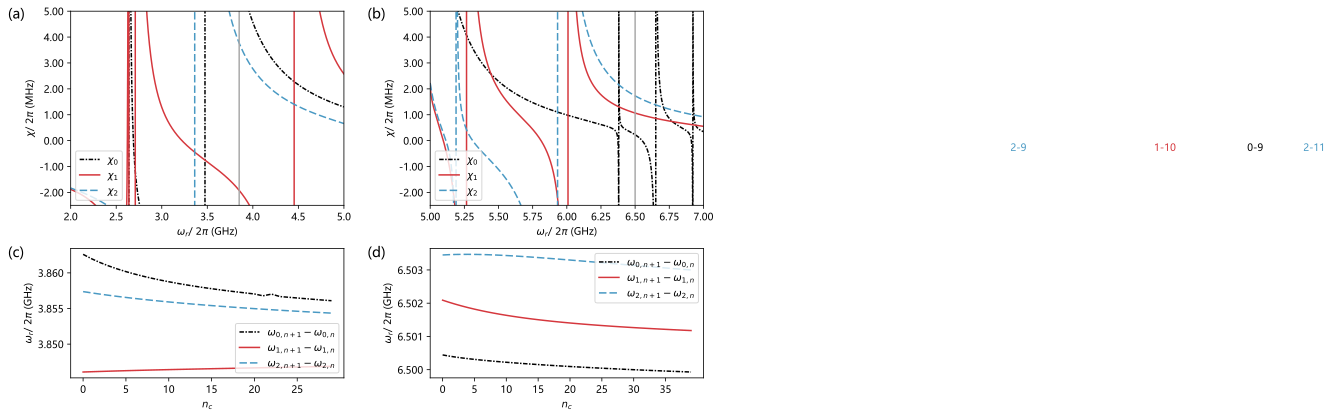

In [117]:
n_evals = 20
qls = [0,1,2]
max_ol = 50
max_ql = 20

fig = plt.figure(figsize=(10, 6)) 
gs0 = fig.add_gridspec(nrows=1, ncols=1,left=0.1, right=0.48,bottom=0.5,top = 0.95)
gs1 = fig.add_gridspec(nrows=1, ncols=1,left=0.6, right=0.98,bottom=0.5,top = 0.95)
ax0 = fig.add_subplot(gs0[0])
ax1 = fig.add_subplot(gs1[0])
gs2 = fig.add_gridspec(nrows=1, ncols=1,left=0.1, right=0.48,bottom=0.1,top = 0.4)
gs3 = fig.add_gridspec(nrows=1, ncols=1,left=0.6, right=0.98,bottom=0.1,top = 0.4)
ax2 = fig.add_subplot(gs2[0])
ax3 = fig.add_subplot(gs3[0])

plt.text(-0.23, 1.02, '(a)', transform=plt.subplot(gs0[0]).transAxes, fontsize=14, va='top', color='black')
plt.text(-0.23, 1.02, '(b)', transform=plt.subplot(gs1[0]).transAxes, fontsize=14, va='top', color='black')
plt.text(-0.23, 1.02, '(c)', transform=plt.subplot(gs2[0]).transAxes, fontsize=14, va='top', color='black')
plt.text(-0.23, 1.02, '(d)', transform=plt.subplot(gs3[0]).transAxes, fontsize=14, va='top', color='black')

####################################################
# a
#
####################################################

def do_plot_a(qbt0):
    matrix0 =  qbt0.matrixelement_table(operator = "n_operator",evals_count=n_evals)
    evals0 = qbt0.eigenvals(n_evals)
    Er_list0 = np.linspace(2,5,int(1e4))
    ylim  = (-0.0025,0.005) # in GHz
    for ql  in qls:
        color  = colors[ql]
        linestyle = linestyles[ql]
        shift_from_qubit_transition = []
        for Er in tqdm(Er_list0, desc = "Er loop"):
            shifts = [get_shift_accurate(matrix0[ql,ql2], evals0[ql2], evals0[ql], Er) for ql2 in range(n_evals)] 
            shift_from_qubit_transition.append(sum(shifts)/100)
        ax0.plot(Er_list0, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = color, linestyle = linestyle)

    # ax0.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax0.set_xlim(Er_list0[0],Er_list0[-1])
    ax0.set_ylim(ylim[0],ylim[1])
    ax0.set_xlabel(rf'$\omega_r$')
    ax0.legend(loc= 'lower left')
    ax0.set_xlabel(rf'$\omega_r$/ $2\pi$ (GHz)')
    ax0.set_yticklabels([f'{val:.2f}' for val in ax0.get_yticks() *1000])
    ax0.set_ylabel(r'$\chi$/ $2\pi$ (MHz)')
    # ax0.scatter(8.46111172,0.0003, marker='*', color='black', s=80,alpha=0.5)
    # y_offset = -0.0006
    # x_offset = 0.01
    # ax0.text(evals0[9]-evals0[2]+x_offset, y_offset,'2-9',color = colors[2])
    # ax0.text(evals0[10]-evals0[1]+x_offset, y_offset,'1-10',color = colors[1])
    # ax0.text(evals0[7]-evals0[0]+x_offset, y_offset,'0-7',color = colors[0])
    # ax0.text(evals0[11]-evals0[2]+x_offset, y_offset,'2-11',color = colors[2])
qbt0 = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/20.5, cutoff = 110,flux = 0.0,truncated_dim=n_evals)
do_plot_a(qbt0)

ax0.axvline(3.85,color='darkgrey')

####################################################
# c 
#
####################################################
system = FluxoniumOscillatorSystem(
    EJ = 3,EC = 3/4,EL = 3/20.5,
    Er = 3.85,
    g_strength = 0.2,
    fluxonium_flux = 0.0,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2'
    )
energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
n_osc_lvls =30
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))   
for j in [0,1,2]:
    ax2.plot(list(range(max_ol-1))[:n_osc_lvls], dressed_osc_frequencies[j][:n_osc_lvls],label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$',color = colors[j], linestyle = linestyles[j])
ax2.set_xticks(list(range(n_osc_lvls))[::5])
# ax2.set_ylim(8.47, 8.482)
ax2.legend(loc = 'lower right')
ax2.set_ylabel(rf'$\omega_r$/ $2\pi$ (GHz)')
ax2.set_xlabel(r'$n_c$')

####################################################
# b 
#
####################################################
EJ_over_EC = 2.7
EJ_over_EL = 45
flux_1 = 0.01
qbt1 = scqubits.Fluxonium(EJ = 4,EC = 4/EJ_over_EC,EL = 4/EJ_over_EL, cutoff = 110,flux = flux_1,truncated_dim=n_evals)
evals1 = qbt1.eigenvals(n_evals)
matrix1 =  qbt1.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list1 = np.linspace(5,7,int(1e4))
ylim  = (-0.0025,0.005)
for ql  in qls:
    color  = colors[ql]
    linestyle = linestyles[ql]
    shift_from_qubit_transition = []
    for Er in tqdm(Er_list1, desc = "Er loop"):
        shifts = [get_shift_accurate(matrix1[ql,ql2], evals1[ql2], evals1[ql], Er) for ql2 in range(n_evals)] 
        shift_from_qubit_transition.append(sum(shifts)/100)
    ax1.plot(Er_list1, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = color, linestyle = linestyle)

# ax1.grid(which='major', linestyle=':', linewidth='0.5', color='black')
ax1.set_xlim(Er_list1[0],Er_list1[-1])
ax1.set_ylim(ylim[0],ylim[1])
ax1.set_xlabel(rf'$\omega_r$')
ax1.legend(loc= 'lower left')
ax1.set_xlabel(rf'$\omega_r$/ $2\pi$ (GHz)')
ax1.set_yticklabels([f'{val:.2f}' for val in ax1.get_yticks() *1000])
ax1.set_ylabel(r'$\chi$/ $2\pi$ (MHz)')
ax1.scatter(10.38695526,0.0002, marker='*', color='black', s=80,alpha=0.5)

y_offset = -0.0004
x_offset = 0.01
ax1.text(evals1[9]-evals1[2]+x_offset, y_offset,'2-9',color = colors[2])
ax1.text(evals1[10]-evals1[1]+x_offset, y_offset,'1-10',color = colors[1])
ax1.text(evals1[9]-evals1[0]+x_offset, y_offset,'0-9',color = colors[0])
ax1.text(evals1[11]-evals1[2]+x_offset, y_offset,'2-11',color = colors[2])

ax1.axvline(6.5,color='darkgrey')
####################################################
# d
#
####################################################

system = FluxoniumOscillatorSystem(
   EJ = 4,EC = 4/EJ_over_EC,EL = 4/EJ_over_EL,
    Er = 6.5,
    g_strength = 0.2,
    fluxonium_flux = flux_1,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '0,2'
    )
energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
n_osc_lvls =40
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))   
for j in [0,1,2]:
    ax3.plot(list(range(max_ol-1))[:n_osc_lvls], dressed_osc_frequencies[j][:n_osc_lvls],label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$',color = colors[j], linestyle = linestyles[j])
ax3.set_xticks(list(range(n_osc_lvls))[::5])
# ax3.set_ylim(10.387, 10.391)
ax3.legend(loc = 'upper right')
ax3.set_ylabel(rf'$\omega_r$/ $2\pi$ (GHz)')
ax3.set_xlabel(r'$n_c$')

fig.savefig('dispersive_shift_with_diagonalization_three_outcome_measurement.pdf')